# 03c — Pit Detector (blob + Random Forest)

Dedicated detector for **wellhead-collapse depressions** — small (1–3 m diameter), circular (0.3–1.5 m deep) pits that mark where casing has deteriorated and the surface subsided into the void. Shape is the polar opposite of a road (compact & circular vs. elongated), so we use a dedicated pipeline.

**Method:**
1. Compute LRM_5 and LRM_11 (small-scale local relief) if missing.
2. Blob-detection via Laplacian-of-Gaussian (`skimage.feature.blob_log`) on `−LRM_5` — sunken pits register as bright blobs. Done twice, once at fine scale (LRM_5) and once coarser (LRM_11), to cover the 1–5 m diameter range.
3. Merge candidates from both scales, deduplicate close-by hits.
4. Extract features per candidate: depth, depth-to-annular-mean, circularity proxy, surrounding slope / TPI / roughness / intensity.
5. Train a Random Forest: positives = candidates near `wellhead_pits.gpkg`; negatives = candidates far from any truth pit.
6. Threshold probability → `candidates_pits.gpkg`, wells attached.
7. Score vs. truth: nearest-neighbour distance, recall at 5 m / 10 m / 25 m.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from scipy import ndimage as ndi
from scipy.ndimage import uniform_filter
from skimage.feature import blob_log
from sklearn.ensemble import RandomForestClassifier
from shapely.geometry import Point
import matplotlib.pyplot as plt
from datetime import datetime
import time, uuid

PROJECT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DERIV = PROJECT / 'data' / 'derivatives'
CAND  = DERIV / 'candidates'
ANNO  = DERIV / 'annotations'
LOGS  = PROJECT / 'docs'
CAND.mkdir(parents=True, exist_ok=True)

DETECTION_METHOD = 'pit_v0.1_blob_rf'
RUN_ID = datetime.utcnow().strftime('%Y%m%dT%H%M%SZ') + '-' + uuid.uuid4().hex[:6]
RNG = np.random.default_rng(42)
print('run_id:', RUN_ID)


run_id: 20260430T180026Z-4cd9c2


C:\Users\colto\AppData\Local\Temp\ipykernel_27408\1736622323.py:23: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  RUN_ID = datetime.utcnow().strftime('%Y%m%dT%H%M%SZ') + '-' + uuid.uuid4().hex[:6]


## 1. Load DEM + compute small-scale LRMs

In [2]:
# Load DEM + existing derivatives we'll use as features
def rd(fname):
    with rasterio.open(DERIV / fname) as ds:
        a = ds.read(1).astype(np.float32); nd = ds.nodata
        if nd is not None: a = np.where(a == nd, np.nan, a)
        return a, ds.transform, ds.crs

dem, T, crs = rd('dem_1m.tif')
H, W = dem.shape
cs = float(T.a); X0, Y1 = T.c, T.f
X1 = X0 + W * cs; Y0 = Y1 - H * cs
print(f'grid {H}x{W} @ {cs} m')

# LRM at small scales (5-cell and 11-cell uniform filters)
def compute_lrm(z, size):
    v = np.isfinite(z).astype(np.float32)
    z0 = np.where(v.astype(bool), z, 0).astype(np.float32)
    sm = uniform_filter(z0, size=size, mode='nearest')
    sc = uniform_filter(v, size=size, mode='nearest')
    smooth = np.where(sc > 0, sm / sc, np.nan)
    return (z - smooth).astype(np.float32)

for size in (5, 11):
    p = DERIV / f'lrm_{size}.tif'
    if not p.exists():
        print(f'computing lrm_{size}...')
        lrm = compute_lrm(dem, size)
        with rasterio.open(
            p, 'w', driver='GTiff', height=H, width=W, count=1, dtype='float32',
            crs=crs, transform=T, nodata=-9999.0, tiled=True, compress='deflate', predictor=3,
        ) as ds:
            ds.write(np.where(np.isfinite(lrm), lrm, -9999.0).astype('float32'), 1)
        print(f'wrote {p.name}')
    else:
        print(f'{p.name} already exists')

lrm5, _, _  = rd('lrm_5.tif')
lrm11, _, _ = rd('lrm_11.tif')

# Features we'll sample at each blob candidate
slope, _, _        = rd('slope.tif')
rough, _, _        = rd('roughness_11.tif')
tpi05, _, _        = rd('tpi_05.tif')
tpi15, _, _        = rd('tpi_15.tif')
local_relief, _, _ = rd('local_relief_10.tif')
intensity, _, _    = rd('intensity_ground.tif')
print('features loaded')


grid 1500x1500 @ 1.0 m
lrm_5.tif already exists
lrm_11.tif already exists


features loaded


## 2. Blob detection (multi-scale) + dedup

In [3]:
# Blob detection on -LRM so depressions become bright.
# Run at two scales: fine (LRM_5, for 1-2 m pits) and coarser (LRM_11, for 2-5 m pits).
# Extended coarse max_sigma from 3.5 to 5.0 to capture larger reserve/brine pits
# (up to ~14 m diameter). Hammack et al. (2014, NETL) document reserve pits at 3-10 m;
# PA DEP records show brine pits at 2-8 m. LoG radius = sigma * sqrt(2).
NEG_LRM5  = -np.where(np.isfinite(lrm5),  lrm5,  0)
NEG_LRM11 = -np.where(np.isfinite(lrm11), lrm11, 0)

# Only accept blobs where LRM is actually < 0 (depressions, not false noise)
depression_mask = (lrm5 < -0.05) | (lrm11 < -0.05)

def run_blob(neg_img, min_sigma, max_sigma, num_sigma, thresh, tag):
    t0 = time.time()
    blobs = blob_log(neg_img, min_sigma=min_sigma, max_sigma=max_sigma,
                     num_sigma=num_sigma, threshold=thresh, overlap=0.5)
    print(f'[{tag}] blob_log returned {len(blobs)} blobs in {time.time()-t0:.1f}s '
          f'(sigma {min_sigma}-{max_sigma}, thresh {thresh})')
    return blobs

blobs_fine   = run_blob(NEG_LRM5,  min_sigma=0.8, max_sigma=2.0, num_sigma=6, thresh=0.04, tag='fine  (LRM_5)')
blobs_coarse = run_blob(NEG_LRM11, min_sigma=1.5, max_sigma=5.0, num_sigma=8, thresh=0.04, tag='coarse(LRM_11)')

# Combine. Each row = (row, col, sigma). Tag which scale produced it.
bf = np.c_[blobs_fine,   np.zeros(len(blobs_fine))]   # scale 0 = fine
bc = np.c_[blobs_coarse, np.ones (len(blobs_coarse))] # scale 1 = coarse
all_blobs = np.vstack([bf, bc]) if len(bf) and len(bc) else (bf if len(bf) else bc)
print(f'combined: {len(all_blobs)} raw blobs')

# Drop blobs outside valid ground-coverage (require depression_mask at centre)
r = all_blobs[:,0].astype(int); c = all_blobs[:,1].astype(int)
keep = depression_mask[np.clip(r,0,H-1), np.clip(c,0,W-1)]
all_blobs = all_blobs[keep]
print(f'after depression mask (LRM < -0.05): {len(all_blobs)}')

# Dedup blobs that are within 1.5 m of each other (keep the deepest)
xs = X0 + (all_blobs[:,1] + 0.5) * cs
ys = Y1 - (all_blobs[:,0] + 0.5) * cs
depths = -lrm5[all_blobs[:,0].astype(int), all_blobs[:,1].astype(int)]
depths = np.nan_to_num(depths, nan=0.0)

from scipy.spatial import cKDTree
tree = cKDTree(np.c_[xs, ys])
pairs = tree.query_pairs(r=1.5)
to_drop = set()
for i, j in pairs:
    if i in to_drop or j in to_drop: continue
    to_drop.add(j if depths[i] >= depths[j] else i)
mask = np.array([i not in to_drop for i in range(len(all_blobs))])
all_blobs = all_blobs[mask]
xs = xs[mask]; ys = ys[mask]
print(f'after dedup @ 1.5 m: {len(all_blobs)} candidate pits')

[fine  (LRM_5)] blob_log returned 46056 blobs in 2.2s (sigma 0.8-2.0, thresh 0.04)


[coarse(LRM_11)] blob_log returned 24658 blobs in 2.9s (sigma 1.5-5.0, thresh 0.04)
combined: 70714 raw blobs
after depression mask (LRM < -0.05): 61284
after dedup @ 1.5 m: 48347 candidate pits


## 3. Feature extraction per candidate

In [4]:
# Feature extraction per candidate
def safe_at(arr, r, c):
    if r < 0 or r >= arr.shape[0] or c < 0 or c >= arr.shape[1]:
        return np.nan
    v = arr[r, c]
    return float(v) if np.isfinite(v) else np.nan

def annular_mean(arr, r0, c0, r_inner, r_outer):
    rr, cc = np.ogrid[:arr.shape[0], :arr.shape[1]]
    d2 = (rr - r0)**2 + (cc - c0)**2
    m = (d2 >= r_inner*r_inner) & (d2 <= r_outer*r_outer) & np.isfinite(arr)
    if not m.any(): return np.nan
    return float(np.mean(arr[m]))

def small_window(arr, r0, c0, half):
    r1 = max(0, r0-half); r2 = min(arr.shape[0], r0+half+1)
    c1 = max(0, c0-half); c2 = min(arr.shape[1], c0+half+1)
    sub = arr[r1:r2, c1:c2]
    return sub[np.isfinite(sub)]

rows = []
for b in all_blobs:
    r, c, sig, scale = int(b[0]), int(b[1]), float(b[2]), int(b[3])
    radius_m = float(sig * np.sqrt(2))  # LoG convention
    # annular rings at 2x and 4x blob radius
    r_inner_px = max(2, int(np.ceil(radius_m * 2 / cs)))
    r_outer_px = max(3, int(np.ceil(radius_m * 4 / cs)))
    depth_5  = -safe_at(lrm5,  r, c) if np.isfinite(lrm5[r,c])  else np.nan
    depth_11 = -safe_at(lrm11, r, c) if np.isfinite(lrm11[r,c]) else np.nan
    ann_lrm5 = annular_mean(lrm5, r, c, r_inner_px, r_outer_px)
    dem_ring = annular_mean(dem,  r, c, r_inner_px, r_outer_px)
    dem_ctr  = safe_at(dem, r, c)
    dem_cut  = (dem_ring - dem_ctr) if (np.isfinite(dem_ring) and np.isfinite(dem_ctr)) else np.nan
    # circularity proxy: std of DEM values around a ring divided by mean depth — low = round
    ring_vals = [safe_at(dem, r + int(round(r_inner_px*np.cos(a))),
                              c + int(round(r_inner_px*np.sin(a)))) for a in np.linspace(0, 2*np.pi, 8, endpoint=False)]
    ring_vals = np.array([v for v in ring_vals if np.isfinite(v)])
    circ_std = float(np.std(ring_vals)) if len(ring_vals) >= 6 else np.nan
    # Local stats in an 11x11 window
    w_slope = small_window(slope, r, c, 5)
    w_rough = small_window(rough, r, c, 5)
    w_tpi05 = small_window(tpi05, r, c, 5)
    w_tpi15 = small_window(tpi15, r, c, 5)
    w_relief= small_window(local_relief, r, c, 5)
    w_int   = small_window(intensity, r, c, 5)
    rows.append(dict(
        cand_id  = len(rows) + 1,
        row      = r, col = c, sigma_px = sig, scale = scale,
        x        = xs[len(rows)], y = ys[len(rows)],
        radius_m = radius_m,
        depth_lrm5   = depth_5,
        depth_lrm11  = depth_11,
        ann_lrm5     = ann_lrm5,
        dem_cut_m    = dem_cut,
        circ_std     = circ_std,
        mean_slope   = float(w_slope.mean())  if w_slope.size  else np.nan,
        mean_rough   = float(w_rough.mean())  if w_rough.size  else np.nan,
        mean_tpi05   = float(w_tpi05.mean())  if w_tpi05.size  else np.nan,
        mean_tpi15   = float(w_tpi15.mean())  if w_tpi15.size  else np.nan,
        mean_relief  = float(w_relief.mean()) if w_relief.size else np.nan,
        mean_intens  = float(w_int.mean())    if w_int.size    else np.nan,
    ))
feats = pd.DataFrame(rows)
print(f'feature rows: {len(feats)}')
print('feature NaN counts:')
print(feats.isna().sum().sort_values(ascending=False).head(6).to_string())

# Drop rows with NaN in any feature we'll train on
FEATURE_COLS = [
    'depth_lrm5', 'depth_lrm11', 'ann_lrm5', 'dem_cut_m', 'circ_std',
    'mean_slope', 'mean_rough', 'mean_tpi05', 'mean_tpi15', 'mean_relief', 'mean_intens',
    'radius_m', 'scale',
]
feats = feats.dropna(subset=FEATURE_COLS).reset_index(drop=True)
feats['cand_id'] = np.arange(1, len(feats)+1, dtype=np.int64)
print(f'after NaN drop: {len(feats)} candidates')


feature rows: 48347
feature NaN counts:
circ_std       434
mean_intens      3
cand_id          0
col              0
row              0
sigma_px         0
after NaN drop: 47910 candidates


## 4. Label from truth, train RF, predict

In [5]:
# Load truth pits, find the nearest blob candidate for each truth (within 3 m) as positive
pits_t_path = ANNO / 'wellhead_pits.gpkg'
if not pits_t_path.exists():
    raise RuntimeError('wellhead_pits.gpkg not found — annotation required')
pits_t = gpd.read_file(pits_t_path).to_crs(crs)
print(f'truth pits: {len(pits_t)}')

from scipy.spatial import cKDTree
cand_xy = feats[['x','y']].to_numpy()
cand_tree = cKDTree(cand_xy)
truth_xy = np.c_[pits_t.geometry.x.values, pits_t.geometry.y.values]

POS_MATCH_M = 5.0   # truth pit matches a candidate within 5 m
NEG_MIN_M   = 15.0  # negatives must be >15 m from any truth pit

d_to_nearest_truth, _ = cKDTree(truth_xy).query(cand_xy, k=1)
feats['d_to_truth_m'] = d_to_nearest_truth

is_pos = feats['d_to_truth_m'] <= POS_MATCH_M
is_neg = feats['d_to_truth_m'] >= NEG_MIN_M
print(f'candidates within {POS_MATCH_M} m of a truth pit (positives): {int(is_pos.sum())} of {len(pits_t)} truth pits matched')
print(f'candidates >= {NEG_MIN_M} m from any truth pit (negatives):  {int(is_neg.sum())}')

# How many truth pits got a match? (recall of the blob pipeline BEFORE classification)
d_from_truth, _ = cand_tree.query(truth_xy, k=1)
truth_has_blob = (d_from_truth <= POS_MATCH_M).sum()
print(f'truth pits with at least one blob within {POS_MATCH_M} m: {truth_has_blob} / {len(pits_t)} '
      f'({100*truth_has_blob/len(pits_t):.1f}%)')

# Training set: all positives + balanced negative sample
n_pos = int(is_pos.sum())
N_NEG = min(5 * n_pos, int(is_neg.sum()))
neg_idx_pool = np.flatnonzero(is_neg.values)
neg_choice = RNG.choice(neg_idx_pool, size=N_NEG, replace=False)
pos_idx = np.flatnonzero(is_pos.values)
train_idx = np.concatenate([pos_idx, neg_choice])
y = np.concatenate([np.ones(n_pos, dtype=np.int8), np.zeros(N_NEG, dtype=np.int8)])
X_train = feats[FEATURE_COLS].iloc[train_idx].to_numpy()
print(f'training set: {len(y)} rows  (pos {n_pos} / neg {N_NEG})')

rf = RandomForestClassifier(
    n_estimators=500, max_depth=15, min_samples_leaf=5,
    class_weight='balanced', n_jobs=-1, oob_score=True, bootstrap=True, random_state=42,
)
t0 = time.time()
rf.fit(X_train, y)
print(f'trained in {time.time()-t0:.1f}s, OOB score: {rf.oob_score_:.4f}')

imp = pd.DataFrame({'feature': FEATURE_COLS, 'importance': rf.feature_importances_}) \
        .sort_values('importance', ascending=False).reset_index(drop=True)
print('feature importances:')
print(imp.to_string(index=False))

# Predict on ALL candidates
feats['proba'] = rf.predict_proba(feats[FEATURE_COLS].to_numpy())[:, 1]


truth pits: 861
candidates within 5.0 m of a truth pit (positives): 311 of 861 truth pits matched
candidates >= 15.0 m from any truth pit (negatives):  45848
truth pits with at least one blob within 5.0 m: 102 / 861 (11.8%)
training set: 1866 rows  (pos 311 / neg 1555)


trained in 0.8s, OOB score: 0.9223
feature importances:
    feature  importance
depth_lrm11    0.228329
 depth_lrm5    0.144118
  dem_cut_m    0.118494
 mean_tpi15    0.107605
 mean_slope    0.068247
mean_relief    0.060409
 mean_tpi05    0.059619
   ann_lrm5    0.055976
   circ_std    0.047471
 mean_rough    0.044759
   radius_m    0.032631
mean_intens    0.031097
      scale    0.001245


## 5. Export + score vs truth

In [6]:
# Threshold probability, keep the rest
PROBA_MIN = 0.5
kept = feats[feats['proba'] >= PROBA_MIN].copy()
print(f'candidates with proba >= {PROBA_MIN}: {len(kept)} / {len(feats)}')

# Attach nearest documented well
wells = gpd.read_file(DERIV / 'wells_in_tile.gpkg').to_crs(crs)
wells_xy = np.c_[wells.geometry.x.values, wells.geometry.y.values]
wtree = cKDTree(wells_xy)
dists, idxs = wtree.query(kept[['x','y']].to_numpy(), k=1)
kept['nearest_well_m'] = dists
kept['nearest_well_id'] = [wells.iloc[int(i)].Well_ident for i in idxs]
kept['inside_positional_uncertainty'] = kept['nearest_well_m'] <= 100.0

# Confidence label
kept['confidence_score'] = kept['proba'].astype(np.float32)
kept['confidence_label'] = np.where(kept['confidence_score'] > 0.70, 'probable', 'candidate')
kept['detection_method'] = DETECTION_METHOD
kept['run_id'] = RUN_ID

# Build GeoDataFrame
geom = [Point(x, y) for x, y in zip(kept['x'], kept['y'])]
kept_gdf = gpd.GeoDataFrame(kept, geometry=geom, crs=crs)

COLS = ['cand_id', 'detection_method', 'run_id', 'confidence_score', 'confidence_label',
        'radius_m', 'depth_lrm5', 'depth_lrm11', 'dem_cut_m', 'circ_std',
        'mean_slope', 'mean_rough', 'mean_tpi05',
        'nearest_well_m', 'nearest_well_id', 'inside_positional_uncertainty',
        'geometry']
kept_gdf = kept_gdf[COLS].sort_values('confidence_score', ascending=False).reset_index(drop=True)
kept_gdf['cand_id'] = np.arange(1, len(kept_gdf)+1, dtype=np.int64)

OUT = CAND / 'candidates_pits.gpkg'
OUT.unlink(missing_ok=True)
kept_gdf.to_file(OUT, layer='candidates_pits', driver='GPKG')
kept_gdf.drop(columns='geometry').to_parquet(CAND / 'candidates_pits.parquet', index=False)
print(f'wrote {OUT.name} ({len(kept_gdf)} pits)')
print(kept_gdf.confidence_label.value_counts().to_string())

# Scoring vs truth
pits_xy = np.c_[kept_gdf.geometry.x.values, kept_gdf.geometry.y.values]
det_tree = cKDTree(pits_xy) if len(pits_xy) else None
d_truth_to_det = np.full(len(pits_t), np.inf)
if det_tree is not None:
    d_truth_to_det, _ = det_tree.query(truth_xy, k=1)
for tol in (5, 10, 25):
    hit = (d_truth_to_det <= tol).sum()
    print(f'TRUTH-PIT RECALL @ {tol} m: {hit} / {len(pits_t)} = {100*hit/len(pits_t):.1f}%')

d_det_to_truth, _ = cKDTree(truth_xy).query(pits_xy, k=1) if len(pits_xy) else (np.array([]), None)
if len(d_det_to_truth):
    prec = (d_det_to_truth <= 10).sum() / len(d_det_to_truth)
    print(f'DETECTION PRECISION @ 10 m (det within 10 m of any truth pit): {100*prec:.1f}%')


candidates with proba >= 0.5: 2504 / 47910


wrote candidates_pits.gpkg (2504 pits)
confidence_label
candidate    1737
probable      767
TRUTH-PIT RECALL @ 5 m: 102 / 861 = 11.8%
TRUTH-PIT RECALL @ 10 m: 102 / 861 = 11.8%
TRUTH-PIT RECALL @ 25 m: 102 / 861 = 11.8%
DETECTION PRECISION @ 10 m (det within 10 m of any truth pit): 15.7%


## 6. QA plot

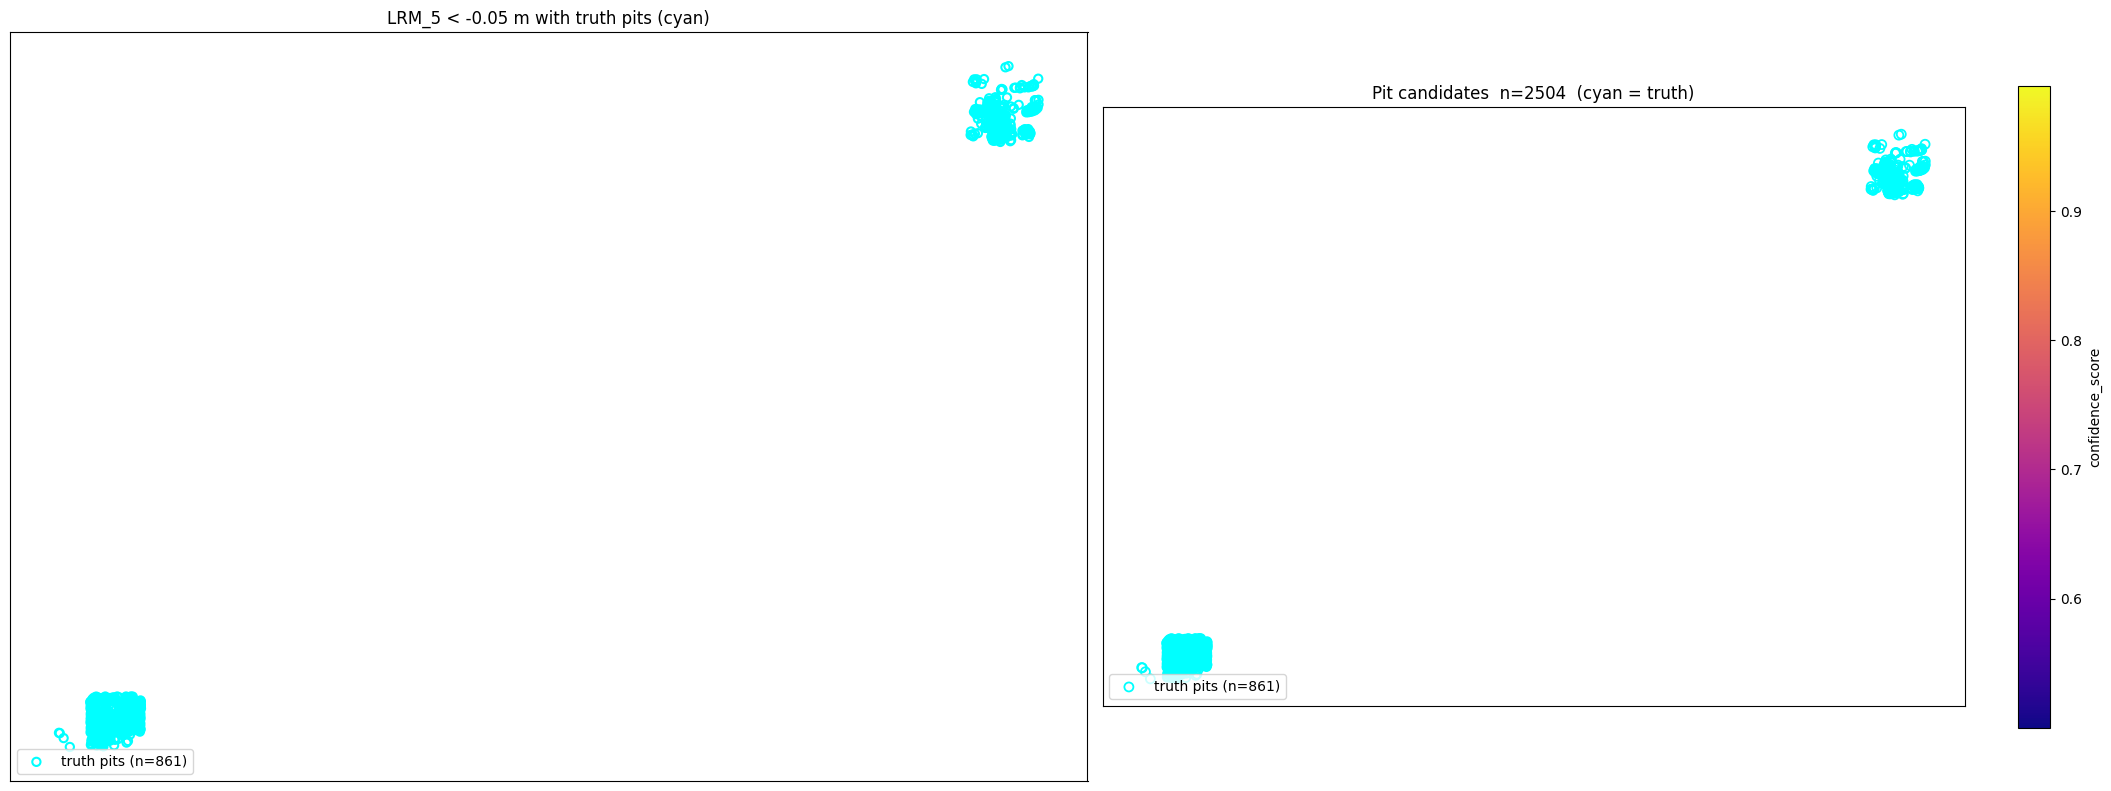

In [7]:
with rasterio.open(DERIV / 'hillshade.tif') as ds:
    hs = ds.read(1)
ext = (X0, X1, Y0, Y1)

fig, axes = plt.subplots(1, 2, figsize=(22, 11))
ax = axes[0]
ax.imshow(hs, cmap='gray', extent=ext, origin='upper')
# LRM_5 heatmap of depressions only
with rasterio.open(DERIV / 'lrm_5.tif') as ds:
    lrm5_disp = ds.read(1); nd = ds.nodata
if nd is not None: lrm5_disp = np.where(lrm5_disp == nd, np.nan, lrm5_disp)
ax.imshow(np.where(lrm5_disp < -0.05, lrm5_disp, np.nan), cmap='magma_r', extent=ext, origin='upper', alpha=0.55, vmin=-0.6, vmax=0)
ax.scatter(pits_t.geometry.x, pits_t.geometry.y, s=35, facecolor='none', edgecolor='cyan', linewidths=1.5, label=f'truth pits (n={len(pits_t)})')
ax.set_title('LRM_5 < -0.05 m with truth pits (cyan)')
ax.set_xticks([]); ax.set_yticks([])
ax.legend(loc='lower left')

ax = axes[1]
ax.imshow(hs, cmap='gray', extent=ext, origin='upper')
if len(kept_gdf):
    kept_gdf.plot(ax=ax, column='confidence_score', cmap='plasma', markersize=22, legend=True,
                  legend_kwds={'label':'confidence_score','shrink':0.6})
ax.scatter(pits_t.geometry.x, pits_t.geometry.y, s=42, facecolor='none', edgecolor='cyan', linewidths=1.3, label=f'truth pits (n={len(pits_t)})')
ax.set_title(f'Pit candidates  n={len(kept_gdf)}  (cyan = truth)')
ax.set_xticks([]); ax.set_yticks([])
ax.legend(loc='lower left')
plt.tight_layout()
plt.savefig(DERIV / 'pits_overview.png', dpi=130, bbox_inches='tight')
plt.show()


## 7. Append log entry

In [8]:
entry = (
    f'\n## {datetime.utcnow():%Y-%m-%d %H:%M UTC} - Pit detector v0.1 (blob + RF)  run {RUN_ID}\n\n'
    f'- Blob detection: {len(all_blobs)} candidates survived dedup+depression_mask\n'
    f'- Truth-pit recall of blob pipeline pre-RF: {truth_has_blob}/{len(pits_t)} ({100*truth_has_blob/len(pits_t):.1f}%) within {POS_MATCH_M:.0f} m\n'
    f'- RF training: {n_pos} pos / {N_NEG} neg candidates, OOB {rf.oob_score_:.4f}\n'
    f'- Top-3 features: ' + ', '.join(f"{r.feature} ({r.importance:.3f})" for r in imp.head(3).itertuples()) + '\n'
    f'- Output: candidates_pits.gpkg ({len(kept_gdf)} pits, {int((kept_gdf.confidence_label=="probable").sum())} probable)\n'
)
with open(LOGS / 'analysis_log.md', 'a', encoding='utf-8') as f:
    f.write(entry)
print(entry)



## 2026-04-30 18:16 UTC - Pit detector v0.1 (blob + RF)  run 20260430T180026Z-4cd9c2

- Blob detection: 48347 candidates survived dedup+depression_mask
- Truth-pit recall of blob pipeline pre-RF: 102/861 (11.8%) within 5 m
- RF training: 311 pos / 1555 neg candidates, OOB 0.9223
- Top-3 features: depth_lrm11 (0.228), depth_lrm5 (0.144), dem_cut_m (0.118)
- Output: candidates_pits.gpkg (2504 pits, 767 probable)



C:\Users\colto\AppData\Local\Temp\ipykernel_27408\3224888683.py:2: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  f'\n## {datetime.utcnow():%Y-%m-%d %H:%M UTC} - Pit detector v0.1 (blob + RF)  run {RUN_ID}\n\n'
